In [ ]:
# 1. Instalación de librerías necesarias
!pip install numpy matplotlib imageio


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image

🚀 Generando animación y calculando matrices...

--- Matriz Resultante Frame 0 ---
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

--- Matriz Resultante Frame 10 ---
[[ 9.18485099e-17 -1.50000000e+00  1.50000000e+00]
 [ 1.50000000e+00  9.18485099e-17  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

--- Matriz Resultante Frame 20 ---
[[-1.0000000e+00 -1.2246468e-16  1.8369702e-16]
 [ 1.2246468e-16 -1.0000000e+00  0.0000000e+00]
 [ 0.0000000e+00  0.0000000e+00  1.0000000e+00]]

--- Matriz Resultante Frame 30 ---
[[-9.18485099e-17  5.00000000e-01 -1.50000000e+00]
 [-5.00000000e-01 -9.18485099e-17  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]

✅ Proceso finalizado. Archivo: 'matrices_y_geometria.gif'


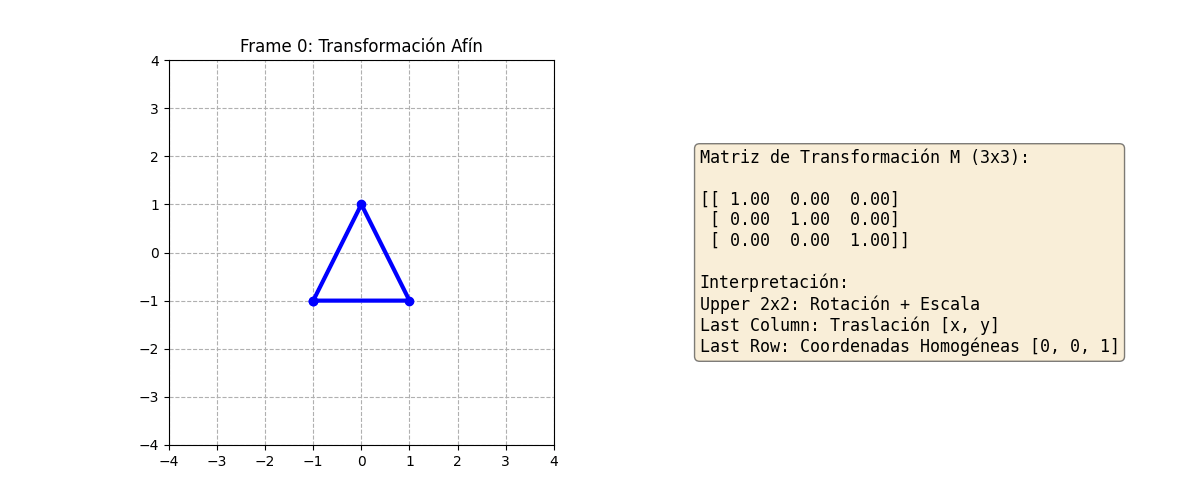

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from IPython.display import Image

# 1. FUNCIONES DE MATRICES (Coordenadas Homogéneas)
def get_translation_matrix(dx, dy):
    return np.array([[1, 0, dx], [0, 1, dy], [0, 0, 1]])

def get_rotation_matrix(theta_deg):
    c, s = np.cos(np.radians(theta_deg)), np.sin(np.radians(theta_deg))
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

def get_scaling_matrix(s):
    return np.array([[s, 0, 0], [0, s, 0], [0, 0, 1]])

# 2. PUNTOS DEL OBJETO (Un triángulo para ver bien la rotación)
# Cada columna es [x, y, 1]
points = np.array([
    [-1, -1, 1], [1, -1, 1], [0, 1, 1], [-1, -1, 1]
]).T

frames = []
n_frames = 40

print("🚀 Generando animación y calculando matrices...")

for i in range(n_frames):
    t = i / n_frames

    # Parámetros variables
    angle = t * 360
    scale = 1 + 0.5 * np.sin(t * np.pi * 2)
    tx = np.sin(t * np.pi * 2) * 1.5

    # Composición: T * R * S
    M_S = get_scaling_matrix(scale)
    M_R = get_rotation_matrix(angle)
    M_T = get_translation_matrix(tx, 0)

    # Matriz Final Resultante
    M_final = M_T @ M_R @ M_S

    # Aplicar a los puntos
    new_points = M_final @ points

    # 3. VISUALIZACIÓN
    fig, (ax_viz, ax_mat) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1]})

    # Subplot 1: El Objeto
    ax_viz.plot(new_points[0, :], new_points[1, :], 'b-o', linewidth=3)
    ax_viz.set_xlim(-4, 4); ax_viz.set_ylim(-4, 4)
    ax_viz.grid(True, linestyle='--')
    ax_viz.set_title(f"Frame {i}: Transformación Afín")
    ax_viz.set_aspect('equal')

    # Subplot 2: La Matriz (Visualización numérica)
    ax_mat.axis('off')
    matrix_str = np.array2string(M_final, formatter={'float_kind':lambda x: f"{x:5.2f}"}, suppress_small=True)

    # Añadimos etiquetas para entender qué hace cada parte de la matriz 3x3
    info_text = (
        f"Matriz de Transformación M (3x3):\n\n"
        f"{matrix_str}\n\n"
        f"Interpretación:\n"
        f"Upper 2x2: Rotación + Escala\n"
        f"Last Column: Traslación [x, y]\n"
        f"Last Row: Coordenadas Homogéneas [0, 0, 1]"
    )
    ax_mat.text(0.1, 0.5, info_text, fontsize=12, family='monospace', va='center', bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))

    # Guardar Frame
    fig.canvas.draw()
    image = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    frames.append(image)

    # Mostrar logs en consola cada 10 frames
    if i % 10 == 0:
        print(f"\n--- Matriz Resultante Frame {i} ---")
        print(M_final)

    plt.close(fig)

# 4. EXPORTAR
imageio.mimsave('matrices_y_geometria.gif', frames, fps=15)
print("\n✅ Proceso finalizado. Archivo: 'matrices_y_geometria.gif'")

# Mostrar resultado
Image(open('matrices_y_geometria.gif','rb').read())